# Tarefa 2: Modelos de Classificação

Treinamento e comparação de cinco algoritmos de classificação para distinguir variedades de grãos de trigo. Todos os modelos são encapsulados em pipelines com escalonamento interno para evitar data leakage.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from pathlib import Path

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import StratifiedKFold, cross_validate

from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix
)

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (8, 6)

BASE_DIR = Path('..')
DATA_DIR = BASE_DIR / 'data' / 'processed'
MODELS_DIR = BASE_DIR / 'models'
MODELS_DIR.mkdir(parents=True, exist_ok=True)

train = pd.read_csv(DATA_DIR / 'seeds_train.csv')
test = pd.read_csv(DATA_DIR / 'seeds_test.csv')

features = [c for c in train.columns if c != 'variety']
X_train, y_train = train[features], train['variety']
X_test, y_test = test[features], test['variety']

print('Treino:', X_train.shape, 'Teste:', X_test.shape)

Treino: (147, 7) Teste: (63, 7)


## Pipelines base com escalonamento interno

Cada modelo utiliza um `Pipeline` com `StandardScaler` para garantir que o escalonamento seja aprendido apenas nos dados de treino de cada fold, evitando data leakage.

In [2]:
pipelines = {
    'KNN': Pipeline([
        ('scaler', StandardScaler()),
        ('model', KNeighborsClassifier())
    ]),
    'SVM': Pipeline([
        ('scaler', StandardScaler()),
        ('model', SVC(random_state=42))
    ]),
    'Random Forest': Pipeline([
        ('scaler', StandardScaler()),
        ('model', RandomForestClassifier(random_state=42))
    ]),
    'Naive Bayes': Pipeline([
        ('scaler', StandardScaler()),
        ('model', GaussianNB())
    ]),
    'Logistic Regression': Pipeline([
        ('scaler', StandardScaler()),
        ('model', LogisticRegression(max_iter=1000, random_state=42))
    ])
}

pipelines

{'KNN': Pipeline(steps=[('scaler', StandardScaler()),
                 ('model', KNeighborsClassifier())]),
 'SVM': Pipeline(steps=[('scaler', StandardScaler()), ('model', SVC(random_state=42))]),
 'Random Forest': Pipeline(steps=[('scaler', StandardScaler()),
                 ('model', RandomForestClassifier(random_state=42))]),
 'Naive Bayes': Pipeline(steps=[('scaler', StandardScaler()), ('model', GaussianNB())]),
 'Logistic Regression': Pipeline(steps=[('scaler', StandardScaler()),
                 ('model', LogisticRegression(max_iter=1000, random_state=42))])}

## Validação cruzada nos dados de treino (5 folds estratificados)

Avaliamos cada pipeline somente no treino para selecionar o melhor candidato antes de tocar no conjunto de teste.

In [3]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = []

for name, pipe in pipelines.items():
    scores = cross_validate(
        pipe, X_train, y_train, cv=cv,
        scoring=['accuracy', 'precision_weighted', 'recall_weighted', 'f1_weighted'],
        n_jobs=1
    )
    cv_results.append({
        'Modelo': name,
        'Acc Média': scores['test_accuracy'].mean(),
        'Acc Std': scores['test_accuracy'].std(),
        'Precisão': scores['test_precision_weighted'].mean(),
        'Recall': scores['test_recall_weighted'].mean(),
        'F1': scores['test_f1_weighted'].mean()
    })

cv_df = pd.DataFrame(cv_results).sort_values('Acc Média', ascending=False)
cv_df.round(4)

,Modelo,Acc Média,Acc Std,Precisão,Recall,F1
4,Logistic Regression,0.9453,0.0466,0.9518,0.9453,0.9458
1,SVM,0.9391,0.0494,0.9469,0.9391,0.9375
3,Naive Bayes,0.9320,0.0218,0.9357,0.9320,0.9318
2,Random Forest,0.9317,0.0431,0.9396,0.9317,0.9319
0,KNN,0.9115,0.0461,0.9228,0.9115,0.9103


## Treinamento final no treino e avaliação no teste

In [4]:
test_results = []
trained_pipelines = {}

for name, pipe in pipelines.items():
    pipe.fit(X_train, y_train)
    y_pred = pipe.predict(X_test)
    trained_pipelines[name] = pipe
    
    test_results.append({
        'Modelo': name,
        'Acurácia': accuracy_score(y_test, y_pred),
        'Precisão': precision_score(y_test, y_pred, average='weighted', zero_division=0),
        'Recall': recall_score(y_test, y_pred, average='weighted', zero_division=0),
        'F1-score': f1_score(y_test, y_pred, average='weighted', zero_division=0)
    })

test_df = pd.DataFrame(test_results).sort_values('Acurácia', ascending=False)
test_df.round(4)

,Modelo,Acurácia,Precisão,Recall,F1-score
4,Logistic Regression,0.9048,0.9048,0.9048,0.9048
0,KNN,0.8889,0.8887,0.8889,0.8885
1,SVM,0.8889,0.8887,0.8889,0.8885
2,Random Forest,0.8413,0.8415,0.8413,0.8402
3,Naive Bayes,0.8413,0.8415,0.8413,0.8402


## Comparação CV vs Teste

In [5]:
comparison = cv_df[['Modelo', 'Acc Média', 'Acc Std']].merge(
    test_df[['Modelo', 'Acurácia']], on='Modelo'
)
comparison['Diff'] = comparison['Acurácia'] - comparison['Acc Média']
comparison.round(4)

,Modelo,Acc Média,Acc Std,Acurácia,Diff
0,Logistic Regression,0.9453,0.0466,0.9048,-0.0405
1,SVM,0.9391,0.0494,0.8889,-0.0502
2,Naive Bayes,0.9320,0.0218,0.8413,-0.0907
3,Random Forest,0.9317,0.0431,0.8413,-0.0905
4,KNN,0.9115,0.0461,0.8889,-0.0226


## Relatórios detalhados

In [6]:
for name, pipe in trained_pipelines.items():
    y_pred = pipe.predict(X_test)
    print(f'\n=== {name} ===')
    print(classification_report(y_test, y_pred, zero_division=0))


=== KNN ===
              precision    recall  f1-score   support

    Canadian       0.86      0.90      0.88        21
        Kama       0.85      0.81      0.83        21
        Rosa       0.95      0.95      0.95        21

    accuracy                           0.89        63
   macro avg       0.89      0.89      0.89        63
weighted avg       0.89      0.89      0.89        63


=== SVM ===
              precision    recall  f1-score   support

    Canadian       0.86      0.90      0.88        21
        Kama       0.85      0.81      0.83        21
        Rosa       0.95      0.95      0.95        21

    accuracy                           0.89        63
   macro avg       0.89      0.89      0.89        63
weighted avg       0.89      0.89      0.89        63


=== Random Forest ===
              precision    recall  f1-score   support

    Canadian       0.78      0.86      0.82        21
        Kama       0.79      0.71      0.75        21
        Rosa       0.95   

## Matrizes de confusão

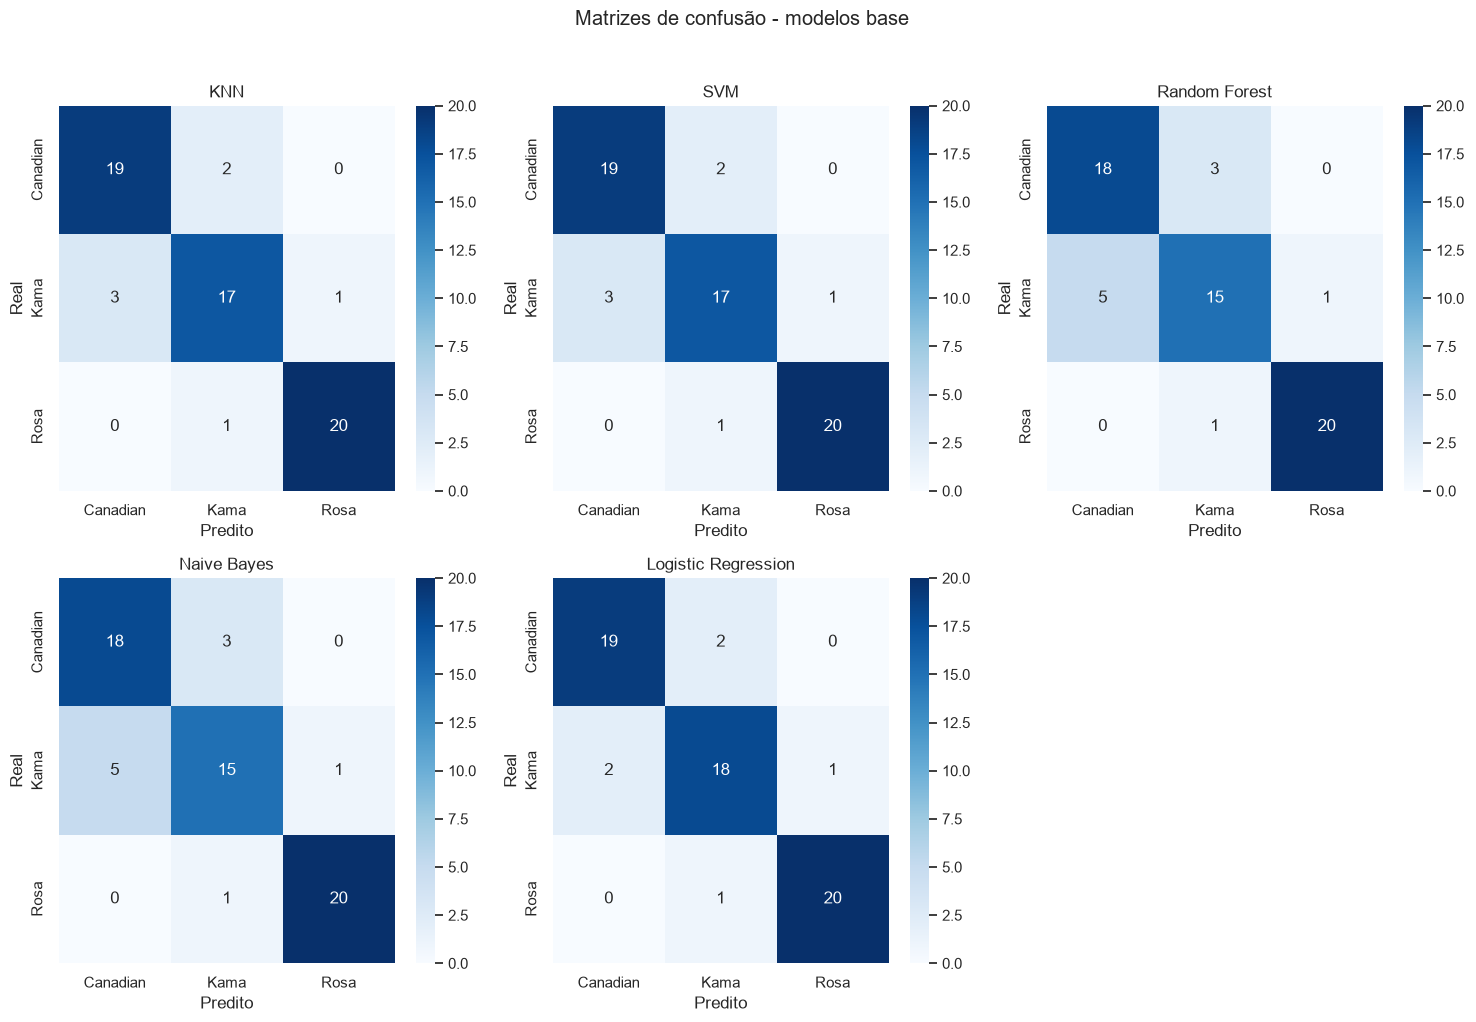

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()
classes = sorted(y_test.unique())

for idx, (name, pipe) in enumerate(trained_pipelines.items()):
    y_pred = pipe.predict(X_test)
    cm = confusion_matrix(y_test, y_pred, labels=classes)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=classes, yticklabels=classes, ax=axes[idx])
    axes[idx].set_title(name)
    axes[idx].set_xlabel('Predito')
    axes[idx].set_ylabel('Real')

axes[-1].axis('off')
plt.suptitle('Matrizes de confusão - modelos base', y=1.02)
plt.tight_layout()
plt.show()

## Salvar modelos base

In [8]:
for name, pipe in trained_pipelines.items():
    safe_name = name.lower().replace(' ', '_')
    joblib.dump(pipe, MODELS_DIR / f'{safe_name}_base.pkl')

print('Modelos base (pipelines) salvos em', MODELS_DIR)

Modelos base (pipelines) salvos em ..\models
